# Actividad 2. Dataset y notebook baseline

**Nombre:** Gerardo González Martínez  
**Matrícula:** A01840096  
**Curso:** TC5061.10, Operaciones de aprendizaje automático (MLOps)  
**Programa:** Maestría en Inteligencia Artificial Aplicada  
**Fecha:** 4 de octubre de 2026  
**Repositorio:** https://github.com/gerardoglezmart/mna-tc5061-actividad2-notebook-baseline

---

Flujo básico de un proyecto de machine learning sobre el dataset Wine Quality del UCI
Machine Learning Repository, con el experimento registrado en MLflow Tracking.


## 1. Carga y descripción del dataset

Wine Quality (vino tinto), el mismo que se revisó en clase. Son mediciones fisicoquímicas de
vinos portugueses con una calificación de calidad asignada por catadores. La copia local viene
de [archive.ics.uci.edu](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv).


In [1]:
import pathlib

import matplotlib.pyplot as plt
import mlflow
import pandas as pd

df = pd.read_csv("data/winequality-red.csv", sep=";")
print("Registros y variables:", df.shape)

Registros y variables: (1599, 12)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Significado de las variables

Las 11 primeras son mediciones de laboratorio y `quality` es la variable objetivo.

| Variable | Significado | Tipo |
|---|---|---|
| fixed acidity | Acidez fija, ácido tartárico en g/dm3 | float |
| volatile acidity | Acidez volátil, ácido acético en g/dm3 | float |
| citric acid | Ácido cítrico en g/dm3 | float |
| residual sugar | Azúcar que queda tras la fermentación en g/dm3 | float |
| chlorides | Cloruros, sal en g/dm3 | float |
| free sulfur dioxide | Dióxido de azufre libre en mg/dm3 | float |
| total sulfur dioxide | Dióxido de azufre total en mg/dm3 | float |
| density | Densidad en g/cm3 | float |
| pH | Acidez en escala de pH | float |
| sulphates | Sulfatos en g/dm3 | float |
| alcohol | Grado alcohólico en porcentaje de volumen | float |
| quality | Calidad asignada por catadores, escala de 0 a 10 | int |


## 2. Análisis exploratorio (EDA)


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


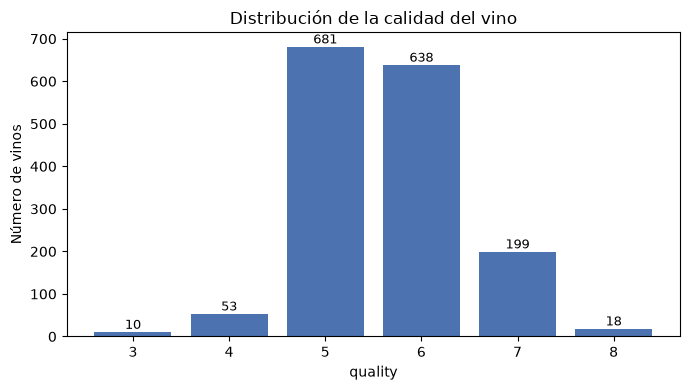

Calidad 7 u 8: 13.6 % de los vinos


In [5]:
conteo = df["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(conteo.index.astype(str), conteo.values, color="#4c72b0")
ax.set_title("Distribución de la calidad del vino")
ax.set_xlabel("quality")
ax.set_ylabel("Número de vinos")
for x, y in zip(conteo.index.astype(str), conteo.values):
    ax.text(x, y + 8, str(y), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Calidad 7 u 8:", round(100 * (df["quality"] >= 7).mean(), 1), "% de los vinos")

Las calidades 5 y 6 concentran el 82 % de los vinos y solo el 13.6 % llega a 7 u 8. Ese
desbalance decide cómo hay que evaluar el modelo más adelante.


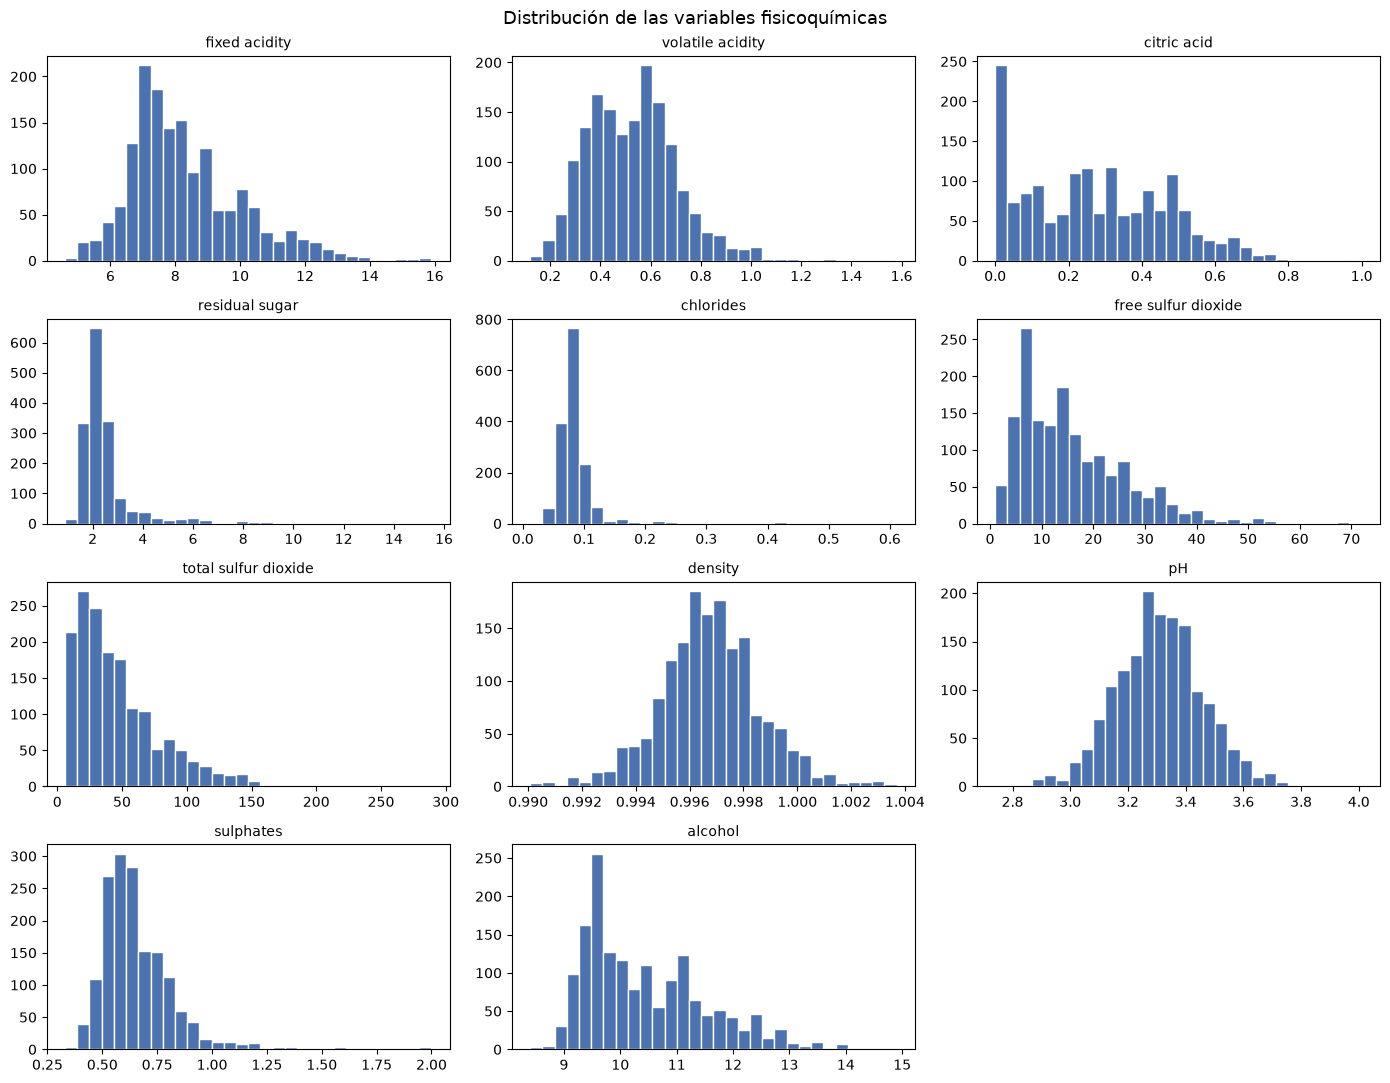

In [6]:
variables = [col for col in df.columns if col != "quality"]

fig, axes = plt.subplots(4, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, variables):
    ax.hist(df[col], bins=30, color="#4c72b0", edgecolor="white")
    ax.set_title(col, fontsize=10)
axes.flat[-1].axis("off")
fig.suptitle("Distribución de las variables fisicoquímicas", fontsize=13)
plt.tight_layout()
plt.show()

`residual sugar`, `chlorides`, `sulphates` y los dos tipos de dióxido de azufre tienen colas
largas a la derecha. Esa asimetría, sumada a que las escalas van de décimas a centenas, obliga
a escalar antes de entrenar.


/tmp/ipykernel_59538/2766077828.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, widths=0.5)
/tmp/ipykernel_59538/2766077828.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, widths=0.5)
/tmp/ipykernel_59538/2766077828.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, widths=0.5)
/tmp/ipykernel_59538/2766077828.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, widths=0.5)
/tmp/ipykernel_59538/2766077828.py:3: Ma

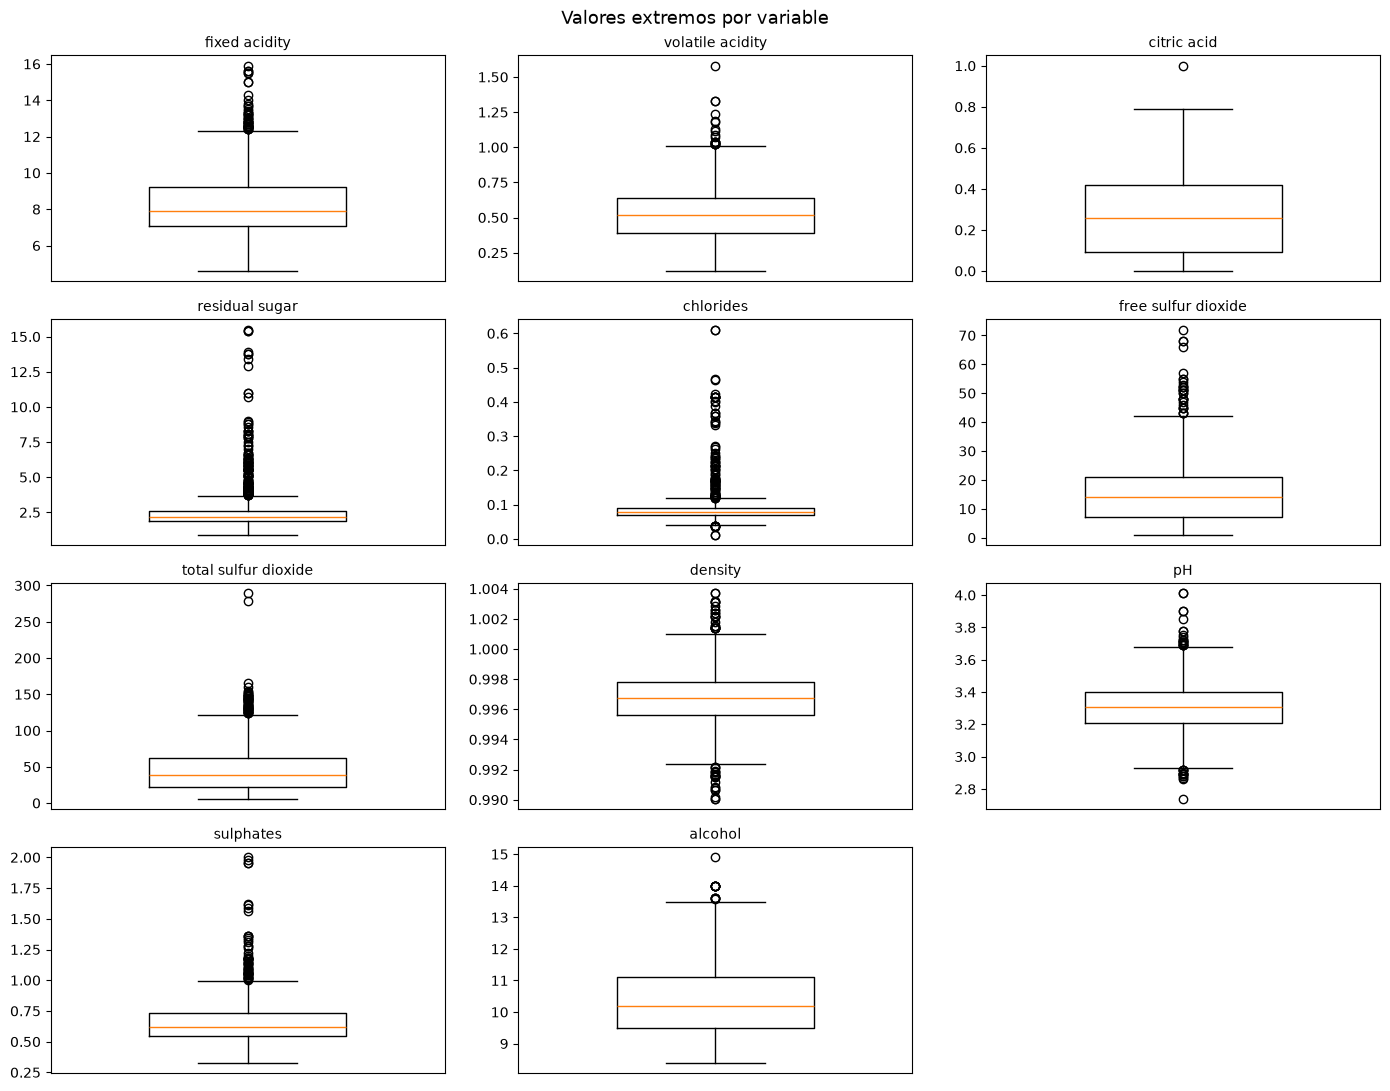

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, variables):
    ax.boxplot(df[col], vert=True, widths=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
axes.flat[-1].axis("off")
fig.suptitle("Valores extremos por variable", fontsize=13)
plt.tight_layout()
plt.show()

Todas las variables tienen puntos fuera de los bigotes. Queda pendiente decidir si son errores
de medición o vinos realmente atípicos, cosa que se resuelve en la limpieza.


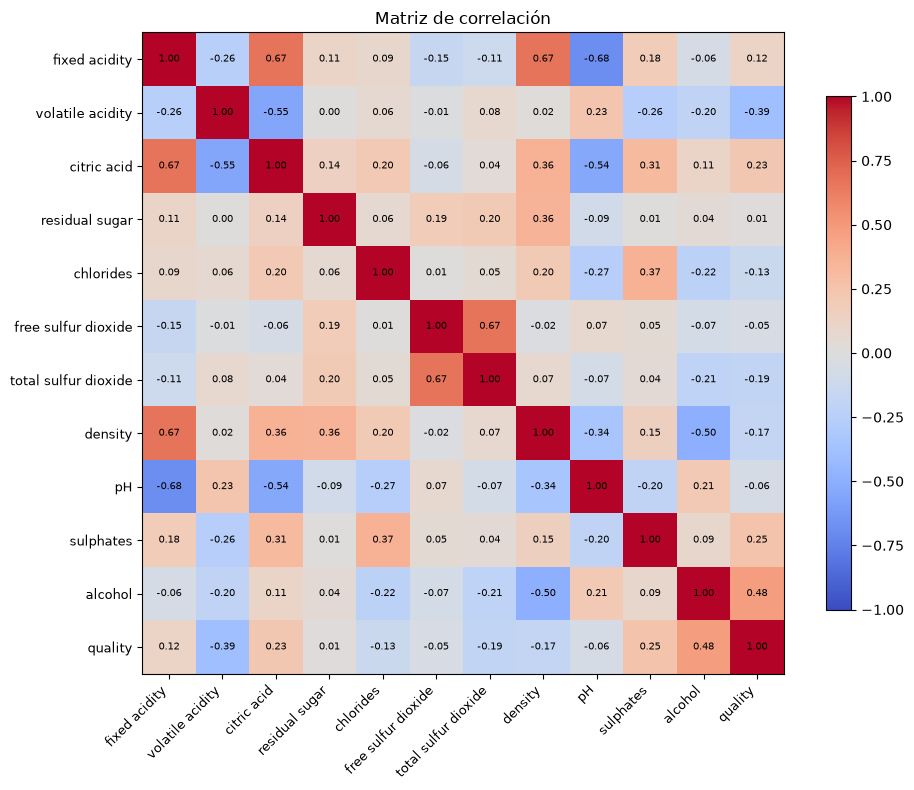

alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391


In [8]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

print(corr["quality"].drop("quality").sort_values(ascending=False).round(3).to_string())

El `alcohol` es la variable que más se relaciona con la calidad, con 0.48, y la
`volatile acidity` es la que más la castiga, con menos 0.39, lo que concuerda con que el exceso
de ácido acético da sabor avinagrado. Ninguna correlación es alta por sí sola, así que el
modelo necesita combinar varias variables.


## 3. Limpieza de datos


In [9]:
print("Valores faltantes:", int(df.isna().sum().sum()))
print("Tipos presentes:", df.dtypes.astype(str).unique().tolist())
print("Columnas no numéricas:",
      [col for col in df.columns if not pd.api.types.is_numeric_dtype(df[col])] or "ninguna")

Valores faltantes: 0
Tipos presentes: ['float64', 'int64']
Columnas no numéricas: ninguna


In [10]:
duplicados = int(df.duplicated().sum())
print("Duplicados:", duplicados, f"({round(100 * duplicados / len(df), 1)} % del total)")

df_limpio = df.drop_duplicates().reset_index(drop=True)
print("Registros antes:", len(df), "| después:", len(df_limpio))

Duplicados: 240 (15.0 % del total)
Registros antes: 1599 | después: 1359


In [11]:
# Regla de 1.5 veces el rango intercuartílico
resumen = []
for col in variables:
    q1, q3 = df_limpio[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = ((df_limpio[col] < q1 - 1.5 * iqr) | (df_limpio[col] > q3 + 1.5 * iqr)).sum()
    resumen.append({"variable": col, "extremos": int(fuera),
                    "porcentaje": round(100 * fuera / len(df_limpio), 1)})

pd.DataFrame(resumen).sort_values("extremos", ascending=False).reset_index(drop=True)

,variable,extremos,porcentaje
0,residual sugar,126,9.3
1,chlorides,87,6.4
2,sulphates,55,4.0
3,total sulfur dioxide,45,3.3
4,fixed acidity,41,3.0
5,density,35,2.6
6,pH,28,2.1
7,free sulfur dioxide,26,1.9
8,volatile acidity,19,1.4
9,alcohol,12,0.9


In [12]:
# El corte en 7 convierte la calificación de los catadores en un problema binario
df_limpio["buen_vino"] = (df_limpio["quality"] >= 7).astype(int)

print(df_limpio["buen_vino"].value_counts().rename({0: "no bueno", 1: "bueno"}).to_string())
print("\nVinos buenos:", round(100 * df_limpio["buen_vino"].mean(), 1), "%")

buen_vino
no bueno    1175
bueno        184

Vinos buenos: 13.5 %


### Decisiones de limpieza

1. **Faltantes.** No hay ninguno en las 12 columnas, así que no se imputa nada. Queda la
   verificación como evidencia.
2. **Tipos.** Las 11 mediciones son `float` y `quality` es `int`, que es lo correcto. Sin
   conversiones.
3. **Duplicados.** Se eliminan los 240 registros repetidos, un 15 % del total. Son filas
   idénticas en las 12 columnas, así que darían peso artificial a esos vinos y, peor aún,
   podrían quedar repartidas entre entrenamiento y prueba, inflando la métrica con datos que
   el modelo ya vio.
4. **Valores extremos.** Se conservan. Son concentraciones químicas plausibles, no errores de
   captura, y eliminarlas sesgaría el modelo contra los vinos que más se alejan del promedio,
   que son justamente los interesantes.
5. **Variable objetivo.** `buen_vino` vale 1 si la calidad es 7 u 8. El corte deja 13.6 % de
   casos positivos y convierte el problema en clasificación binaria.


## 4. Modelo base


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df_limpio[variables]
y = df_limpio["buen_vino"]

# Se divide antes de escalar para que el conjunto de prueba no influya en el escalado.
# El estratificado conserva el 13.6 % de vinos buenos en ambos lados.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entrenamiento:", len(X_train), "registros |", round(100 * y_train.mean(), 1), "% buenos")
print("Prueba:       ", len(X_test), "registros |", round(100 * y_test.mean(), 1), "% buenos")

Entrenamiento: 1087 registros | 13.5 % buenos
Prueba:        272 registros | 13.6 % buenos


In [14]:
# Referencia trivial: predecir siempre la clase mayoritaria
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

# Modelo base. El escalado va dentro del Pipeline para que se ajuste solo con entrenamiento
logistica = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42)),
])
logistica.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('escalado', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 5. Evaluación del modelo

Tres métricas, porque con una clase que ocupa el 86 % de los casos el accuracy por sí solo no
dice nada.


In [15]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score,
)

def evaluar(modelo, nombre):
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]
    return {
        "modelo": nombre,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "f1": round(f1_score(y_test, pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, proba), 4),
    }

pd.DataFrame([evaluar(dummy, "DummyClassifier"), evaluar(logistica, "LogisticRegression")])

,modelo,accuracy,f1,roc_auc
0,DummyClassifier,0.864,0.0000,0.500
1,LogisticRegression,0.875,0.3462,0.886


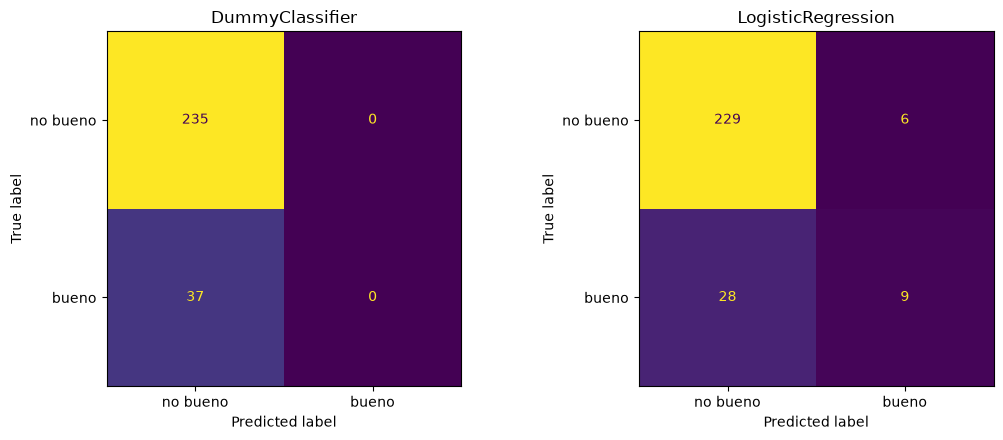

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (modelo, nombre) in zip(axes, [(dummy, "DummyClassifier"), (logistica, "LogisticRegression")]):
    matriz = confusion_matrix(y_test, modelo.predict(X_test))
    ConfusionMatrixDisplay(matriz, display_labels=["no bueno", "bueno"]).plot(ax=ax, colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig("artefactos/matriz_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

In [17]:
reporte = classification_report(y_test, logistica.predict(X_test),
                                target_names=["no bueno", "bueno"], zero_division=0)
print(reporte)

pathlib.Path("artefactos/classification_report.txt").write_text(reporte)

              precision    recall  f1-score   support

    no bueno       0.89      0.97      0.93       235
       bueno       0.60      0.24      0.35        37

    accuracy                           0.88       272
   macro avg       0.75      0.61      0.64       272
weighted avg       0.85      0.88      0.85       272



326

### Interpretación

El `DummyClassifier` llega a 0.864 de accuracy sin identificar un solo vino bueno. Su F1 es
cero y su ROC-AUC es 0.50, el valor del azar. Ese número alto sale completo del desbalance, y
es el tipo de métrica que engaña si se mira sola.

La regresión logística sube el accuracy apenas a 0.875, pero el F1 pasa de 0 a 0.346 y el
ROC-AUC llega a 0.886, lo que significa que ordena bien los vinos según su probabilidad de ser
buenos. La matriz de confusión muestra dónde está la deuda: detecta pocos de los vinos buenos
y deja muchos falsos negativos. Como punto de partida sirve, porque ya existe un número contra
el cual comparar cualquier modelo más complejo, y queda claro que el siguiente paso es atacar
el desbalance, por ejemplo con `class_weight` o moviendo el umbral de decisión.


## 6. Registro del experimento en MLflow


In [18]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("wine-quality-baseline")

def registrar(modelo, nombre, parametros):
    with mlflow.start_run(run_name=nombre):
        mlflow.log_params({
            "modelo": nombre,
            "umbral_calidad": 7,
            "duplicados_eliminados": duplicados,
            "registros_entrenamiento": len(X_train),
            "registros_prueba": len(X_test),
            **parametros,
        })

        metricas = evaluar(modelo, nombre)
        mlflow.log_metric("accuracy", metricas["accuracy"])
        mlflow.log_metric("f1", metricas["f1"])
        mlflow.log_metric("roc_auc", metricas["roc_auc"])

        mlflow.log_artifact("artefactos/matriz_confusion.png")
        mlflow.log_artifact("artefactos/classification_report.txt")

        print(nombre, "registrado con Run ID", mlflow.active_run().info.run_id)

registrar(dummy, "DummyClassifier", {"strategy": "most_frequent"})
registrar(logistica, "LogisticRegression", {"escalado": "StandardScaler", "max_iter": 1000})

2026/10/04 17:54:37 INFO mlflow.tracking.fluent: Experiment with name 'wine-quality-baseline' does not exist. Creating a new experiment.


DummyClassifier registrado con Run ID 7be60a1c81d44718aba61d064a9fe164
🏃 View run DummyClassifier at: http://127.0.0.1:5000/#/experiments/1/runs/7be60a1c81d44718aba61d064a9fe164
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


LogisticRegression registrado con Run ID 13d77411e48b4fe38757500eafe3cd79
🏃 View run LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/13d77411e48b4fe38757500eafe3cd79
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Evidencia del servidor de tracking

El servidor se levanta desde la carpeta del notebook, con el ambiente virtual activado:

```bash
mlflow ui --port 5000
```

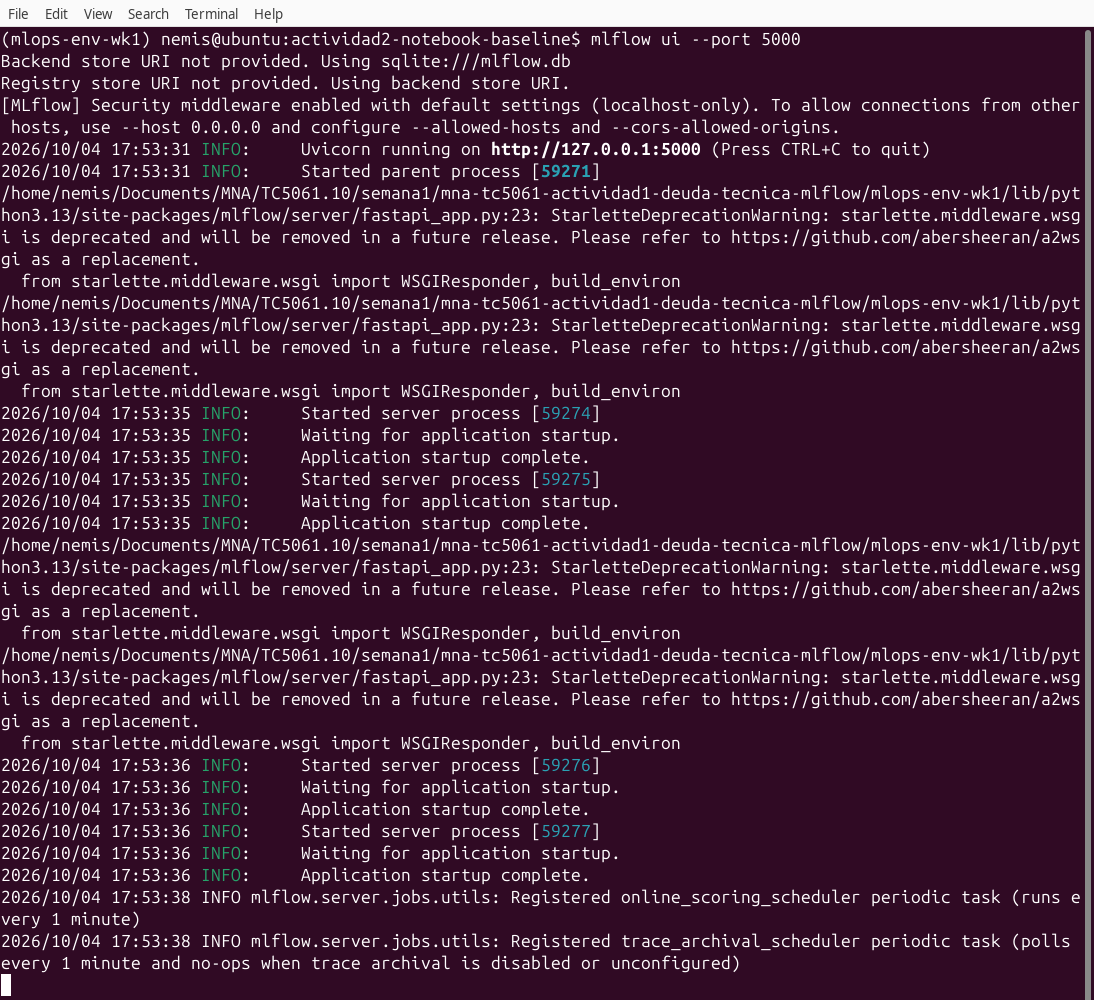


### Evidencia de la interfaz de MLflow

Las dos corridas quedan en el experimento `wine-quality-baseline`, con sus parámetros, sus
métricas y los dos artefactos.

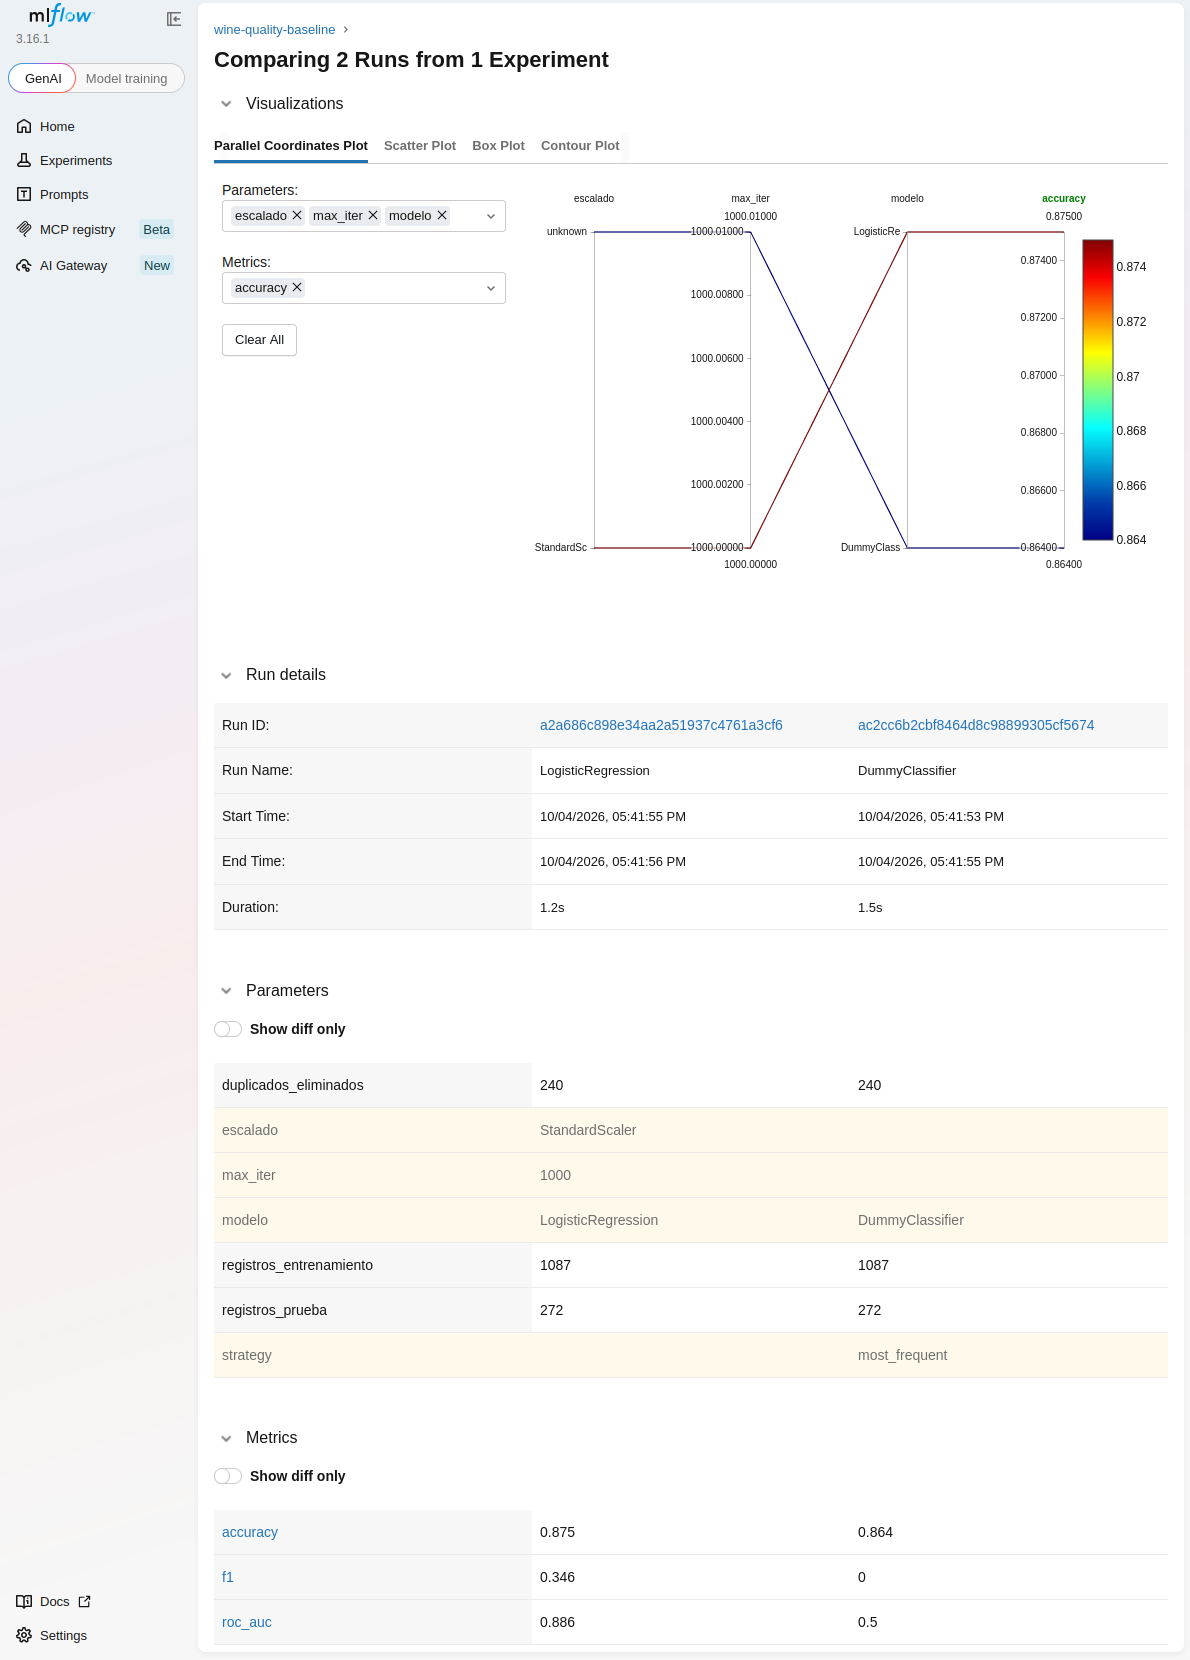


## 7. Reflexión

Este notebook funciona hoy porque todo cabe en un archivo y lo corre una sola persona. Ahí
mismo está su problema. La limpieza vive en celdas que alguien puede ejecutar en otro orden,
el dataset es una copia que nadie versiona, y si mañana cambio el corte de calidad de 7 a 6 no
queda registro de por qué. Lo único que sí quedó guardado son las dos corridas de MLflow.

Con prácticas de MLOps cambiaría tres cosas. Versionar los datos junto con el código, para que
cada corrida apunte a una versión exacta del dataset y no a lo que hubiera en la carpeta ese
día. Sacar la limpieza y el entrenamiento a un script con pasos reproducibles, dejando el
notebook solo para explorar y explicar. Y registrar el modelo con una versión identificable en
lugar de guardarlo como archivo suelto.

En mi trabajo esto se ve seguido. He estado en procesos donde preparar los datos dependía de
varias personas y de pasos manuales, y donde publicar una versión nueva era copiar un archivo
a una carpeta compartida. El modelo casi nunca era el problema. Lo difícil era responder qué
datos lo entrenaron y qué versión estaba corriendo, y eso es justo lo que un registro como
MLflow convierte en una consulta.


## Declaración de uso de herramientas de inteligencia artificial

En esta entrega se utilizó Claude Code de Anthropic, con el modelo Claude Opus 5.5, para la
generación parcial de código, orientada a mejorar el código propuesto y a plantear
alternativas basadas en decisiones de optimización.

Anthropic. (2026). Claude Code (Claude Opus 5.5) [Modelo de lenguaje grande], utilizado para
generación parcial de código, mejora del código propuesto y alternativas de optimización.
https://claude.com/claude-code
